### Co-purchasing analysis
Here we use a financial marketing dataset:

> Amazon product co-purchasing network and ground-truth communities
> 
> J. Yang and J. Leskovec. Defining and Evaluating Network Communities based on Ground-truth. ICDM, 2012.

To evaluate how the cluster of items (communities) can grow through the co-purchasing behavior of customers. 


In [2]:
import numpy as np
import scipy.sparse as sp
import warnings
# Suppress specific TqdmWarning related to IProgress
warnings.filterwarnings("ignore", category=UserWarning, module="tqdm")
from copurchase_data_process import read_adjacent_mat,read_label,build_feature_vectors


%reload_ext autoreload
%autoreload 2

adj = read_adjacent_mat("data/co-purchasing/graph.txt")

NODES_NUM = adj.shape[0]

labels, train_mask, test_mask = \
    read_label("data/co-purchasing/cmty5000.txt",\
    NODES_NUM,
    class_num = 500,
    class_max_rate = 0.8,
    class_max_samp = 0,
    missing_class = 0)

CLASS_NUM = np.max(labels) # zero is unknown class. No ground truth.

labels = labels - 1 # 0-based index so that the cross entropy loss work correct.
# see some line of the adj matrix,check whether it is correct
print("Edge Connect to The First Node :",adj[0].sum())
print("Node Number: ",NODES_NUM)
print("Label Number: ", CLASS_NUM)
print("Train Node Number: ",np.sum(train_mask))   
print("Test Node Number: ",np.sum(test_mask))

Items belongs to the first class:  214
Items belongs to the last class:  18
Edge Connect to The First Node : 8
Node Number:  334863
Label Number:  500
Train Node Number:  3571
Test Node Number:  981


In [9]:
# get rid of some nodes with no labels
no_label_mask = np.where((train_mask+test_mask) == False)[0]
# select 80% of no_label_mask
num_samples = int(0.8 * len(no_label_mask))
no_label_mask = np.random.choice(no_label_mask,size=num_samples,replace=True)
# filter the node out
print("delete node: ",len(no_label_mask))
# NODES_NUM -= len(no_label_mask)
adj,labels,train_mask,test_mask = 
print("rest node: ", len(adj))

delete node: 198223


In [6]:
# only use adjacent matrix to generate feature vectors
features_adj = build_feature_vectors(adj, NODES_NUM)
print("Feature Shape: ",features_adj.shape)

# save this feature matrix to disk, so that we can use it in the future.
np.save("data/co-purchasing/features.npy",features_adj)

Trainslate to networkx graph


Computing transition probabilities: 100%|██████████| 334863/334863 [00:53<00:00, 6203.15it/s] 
C:\Users\Winfred X\AppData\Roaming\Python\Python310\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Build Node2Vec model
Finish feature random walk
Extract the features out
Feature Shape:  (334863, 16)


In [5]:
from train import train_fc,train_base
from scipy.sparse import coo_matrix
import torch
# read the feature matrix from disk
FEATURE_NUM = 16
torch.cuda.empty_cache()
features_adj = np.load("data/co-purchasing/features.npy",allow_pickle=True).tolist()

features_adj = coo_matrix(features_adj,shape=(NODES_NUM,FEATURE_NUM))

# print("Feature Shape: ",features_adj.shape)

In [ ]:

layer_dims = [features_adj.shape[1], 80, 80, CLASS_NUM]
#print("Layer dimensions: ", layer_dims)
base_model, train_acc_list,test_acc_list, loss_list ,predict_result = train_base(
    layer_dims=layer_dims,
    data=(adj, features_adj, labels, train_mask , test_mask),
    dropout_rate=0.3,
    learning_rate= 0.001,
    weight_decay=  5e-4,
    self_importance= 0.8,
    epoch_num = 70,
)
non_zero_num = base_model.layers[0].input_nonezero_num
torch.save(base_model.state_dict(), "data/co-purchasing/base_model.pth")

In [ ]:
# also use SGC here.
from train import train_sgc
# id_feature = identity_matrix = sp.identity(NODES_NUM, format='csr')
layer_dims = [features_adj.shape[1], CLASS_NUM]
sgc_model, train_acc_list,test_acc_list, loss_list ,predict_result = train_sgc(
    layer_dims=layer_dims,
    data=(adj, features_adj, labels, train_mask , test_mask),
    degree = 8,
    learning_rate= 0.01,
    weight_decay=  5e-4,
    self_importance= 1.0,
    epoch_num = 50,
)

# save the model and the predict result to disk
torch.save(sgc_model.state_dict(), "data/co-purchasing/sgc_model.pth")
np.save("data/co-purchasing/sgc_predict_result.npy",predict_result)

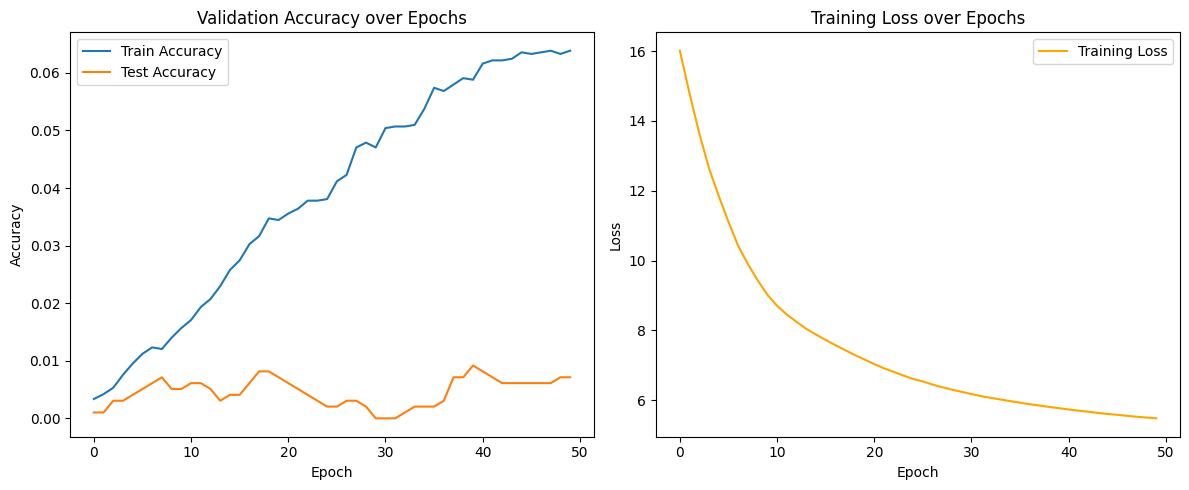

In [5]:
import matplotlib.pyplot as plt

# 绘制验证准确率曲线
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_acc_list, label='Train Accuracy')
plt.plot(test_acc_list, label='Test Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy over Epochs')
plt.legend() #加图例

# 绘制损失值曲线
plt.subplot(1, 2, 2)
plt.plot(loss_list, label='Training Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.legend()

plt.tight_layout() #调整子图布局
plt.show()

In [7]:
# use seaborn to see 
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import seaborn as sns

# convert feature to dense matrix
def embedding_to_2d(features):
    node_embeddings = np.asarray(features)
    # Use t-SNE for dimensionality reduction
    pca = PCA(n_components=16)
    tsne = TSNE(n_components=2, random_state=0)
    node_embeddings_2d = tsne.fit_transform(node_embeddings)

    # Optionally, use PCA before t-SNE for better results
    node_embeddings_pca = pca.fit_transform(node_embeddings)
    node_embeddings_2d = tsne.fit_transform(node_embeddings_pca)
    return node_embeddings_2d

def plot_cluster(node_embeddings_2d,labels):
    # Get cluster labels (assuming you have them from a clustering algorithm)
    cluster_labels = labels

    # Create a scatter plot
    plt.figure(figsize=(8, 6))
    palette = sns.color_palette("hsv", len(set(cluster_labels)))  # Choose a color palette
    sns.scatterplot(x=node_embeddings_2d[:, 0], y=node_embeddings_2d[:, 1], hue=cluster_labels, palette=palette, 
        legend=False,)
    # plt.title('t-SNE Visualization of Classification in Citeseer()')
    plt.show()

node_embeddings_2d = None

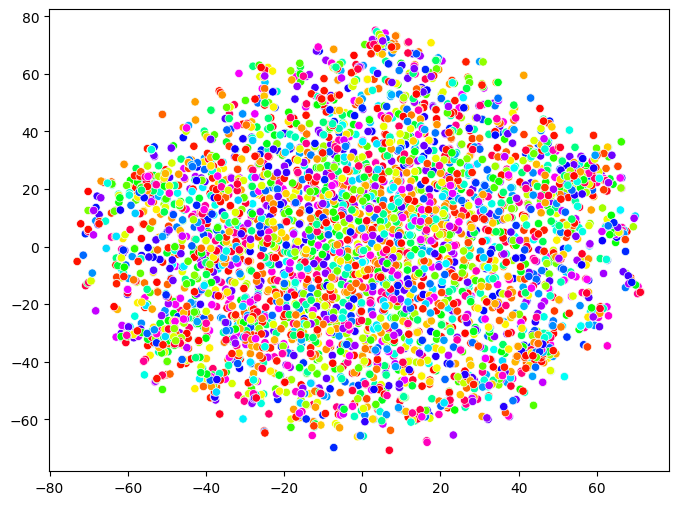

In [8]:
# select only the node that train_mask and test_mask is true
combined_mask = np.where(train_mask + test_mask)
select_features = features_adj.todense()[combined_mask]
select_labels = labels[combined_mask]
# print(select_features.shape,select_labels.shape)
if node_embeddings_2d == None:
    node_embeddings_2d = embedding_to_2d(select_features)
plot_cluster(node_embeddings_2d,select_labels)